# ANES 2022 Pilot


Citation:

American National Election Studies. 2022. ANES 2022 Pilot Study [dataset and documentation].
December 14, 2022 version. www.electionstudies.org

In [1]:
%load_ext nb_black
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/examples/anes_2024_pilot.ipynb) -- but you will have to download the data yourself, because I am not allowed to redistribute it.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

In [3]:
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlesize"] = 11

<IPython.core.display.Javascript object>

In [4]:
aibm_light_gray = "#F3F4F3"
aibm_medium_gray = "#767676"
aibm_green = "#0B8569"
light_green = "#AAC9B8"
aibm_orange = "#C55300"
light_orange = "#F4A26B"
aibm_purple = "#9657A5"
light_purple = "#CFBCD0"
aibm_blue = "#4575D6"
light_blue = "#C9D3E8"

<IPython.core.display.Javascript object>

In [5]:
def decorate(**options):
    """Decorate the current axes.

    Call decorate with keyword arguments like
    decorate(title='Title',
             xlabel='x',
             ylabel='y')

    The keyword arguments can be any of the axis properties
    https://matplotlib.org/api/axes_api.html
    """
    ax = plt.gca()
    ax.set(**options)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels)

    plt.tight_layout()

<IPython.core.display.Javascript object>

In [6]:
def savefig(filename, **options):
    if "dpi" not in options:
        options["dpi"] = 300
    plt.savefig(filename, **options)

<IPython.core.display.Javascript object>

In [7]:
from utils import underride


def value_counts(series, **options):
    """Make a series of values and the number of times they appear.

    Returns a DataFrame because they get rendered better in Jupyter.

    series: Pandas Series

    returns: Pandas DataFrame
    """
    options = underride(options, dropna=False)
    series = series.value_counts(**options).sort_index()
    series.index.name = "values"
    series.name = "counts"
    return pd.DataFrame(series)

<IPython.core.display.Javascript object>

## Read the Data

[You can get the data here](https://electionstudies.org/data-center/2024-pilot-study/) -- but you'll need to create an account.

We drop the cases that have invalid weights:

> There are 1,500 weighted cases on the file and an additional 409 unweighted cases not
intended for population inference. The weighted cases are intended to represent the
population. The 1,500 weighted cases completed the questionnaire, passed a quality control
check by YouGov, and were selected using the df matching procedure described below in
the Sampling and Weighting section. The additional 409 cases are described below and include
296 partial interviews and 113 people who completed the questionnaire but were not selected
using the df matching procedure. The additional cases are included to allow
methodological analysis, such as a review of the randomization used in question wording
experiments. Weights are not provided for the additional 409 cases, as they are not intended to
contribute to population inference. The unmatched cases can be distinguished from the main
cases by their missing weights in the weight variable or using the variable df_type.

Recommended description from the codebook:

> “The survey was conducted using non-probability sampling. This method produces a
df that looks similar to a probability df on the matched characteristics but may
still differ in unknown ways on unmatched characteristics.”


In [8]:
filename = "anes_pilot_2022_stata_20221214.dta"
df_all = pd.read_stata(filename, convert_categoricals=False)
df_all.shape

(1585, 577)

<IPython.core.display.Javascript object>

In [9]:
varname = "ownstem_abortion"
value_counts(df_all[varname])

,counts
values,
-7.0,1
1.0,722
2.0,458
3.0,404


<IPython.core.display.Javascript object>

## Weighted Cases

In [10]:
df = df_all.dropna(subset=["weight"]).copy()

<IPython.core.display.Javascript object>

In [11]:
df["weight"].describe()

count    1500.000000
mean        1.000001
std         0.513651
min         0.298400
25%         0.653300
50%         0.886400
75%         1.181225
max         4.490300
Name: weight, dtype: float64

<IPython.core.display.Javascript object>

In [12]:
value_counts(df["gender"])

,counts
values,
1.0,691
2.0,809


<IPython.core.display.Javascript object>

In [13]:
df["birthyr_dropdown"].describe()

count    1500.000000
mean     1971.979333
std        17.687910
min      1930.000000
25%      1958.000000
50%      1969.000000
75%      1988.000000
max      2004.000000
Name: birthyr_dropdown, dtype: float64

<IPython.core.display.Javascript object>

In [14]:
df["age"] = 2022 - df["birthyr_dropdown"]
value_counts(df["age"])

,counts
values,
18.0,14
19.0,24
20.0,15
21.0,17
22.0,29
...,...
86.0,2
87.0,2
88.0,1


<IPython.core.display.Javascript object>

pid3 
```
63 ‐7 No Answer
508 1 Democrat
430 2 Republican
428 3 Independent
66 4 Other
90 5 Not sure
```

In [15]:
value_counts(df["pid3"])

,counts
values,
-7.0,62
1.0,477
2.0,399
3.0,412
4.0,63
5.0,87


<IPython.core.display.Javascript object>

In [16]:
df_male = df.query("gender == 1")
df_female = df.query("gender == 2")
len(df_male), len(df_female)

(691, 809)

<IPython.core.display.Javascript object>

In [17]:
df_young_male = df.query("gender == 1 and age < 40")
df_young_female = df.query("gender == 2 and age < 40")
len(df_young_male), len(df_young_female)

(211, 285)

<IPython.core.display.Javascript object>

In [18]:
df_female["ownstem_abortion"].value_counts()

ownstem_abortion
 1.0    381
 3.0    218
 2.0    209
-7.0      1
Name: count, dtype: int64

<IPython.core.display.Javascript object>

## Estimation

In [19]:
from scipy.stats import beta

# simple implementation to double-check the more complex version


def estimate_proportion_jeffreys(success_series, weights_series):
    n = success_series.count()
    k = success_series.sum()
    p = k / n
    dist = beta(k + 1 / 2, n - k + 1 / 2)
    lower, upper = dist.ppf([0.025, 0.975])
    return p, lower, upper

<IPython.core.display.Javascript object>

In [20]:
from scipy.stats import norm


def estimate_proportion(success_series, weights_series, confidence_level=0.95):
    """
    Calculate the weighted proportion and Wilson score interval for weighted data.

    Parameters:
    success_series (pd.Series): A boolean series where True represents a success.
    weights_series (pd.Series): A series of weights corresponding to the success_series.
    confidence_level (float): The confidence level for the Wilson score interval

    Returns:
    weighted_proportion (float): The weighted proportion of successes.
    lower: The lower and upper bounds of the Wilson score interval.
    """
    # Ensure the series are aligned and of correct type
    success_series = success_series.astype(float)
    weights_series = weights_series.astype(float)

    # Calculate weighted proportion
    total_weight = weights_series.sum()
    weighted_successes = (success_series * weights_series).sum()
    p = weighted_successes / total_weight

    # Calculate the z-score for the given confidence level
    z = norm.ppf(1 - (1 - confidence_level) / 2)

    # Wilson score interval adjusted for weighted data
    denominator = 1 + z**2 / total_weight
    center = (p + z**2 / (2 * total_weight)) / denominator
    sd = (
        np.sqrt((p * (1 - p) + z**2 / (4 * total_weight)) / total_weight)
        / denominator
    )

    # Lower and upper bounds of the Wilson interval
    lower = center - z * sd
    upper = center + z * sd

    return p, lower, upper

<IPython.core.display.Javascript object>

Some people seem to follow what’s going on in government and public affairs most of the
time, whether there’s an election going on or not. Others aren’t that interested. Would you say you
follow what’s going on in government and public affairs most of the time, some of the time, only now
and then, or hardly at all?

```
1. Most of the time
2. Some of the time
3. Only now and then
4. Hardly at all
```

In [21]:
df["follow"].value_counts(dropna=False)

follow
1.0    720
2.0    440
3.0    208
4.0    132
Name: count, dtype: int64

<IPython.core.display.Javascript object>

In [22]:
estimate_proportion(df["follow"] == 1, df["weight"])

(0.4679693760408319, 0.4428322986075227, 0.4932700932761678)

<IPython.core.display.Javascript object>

In [23]:
estimate_proportion_jeffreys(df["follow"] == 1, df["weight"])

(0.48, 0.4547761407026026, 0.5053009576749498)

<IPython.core.display.Javascript object>

In [24]:
estimate_proportion(df_female["ownstem_abortion"] == 3, df_female["weight"])

(0.2785364460420787, 0.24801762769175117, 0.3112562339085232)

<IPython.core.display.Javascript object>

In [25]:
estimate_proportion_jeffreys(df_female["ownstem_abortion"] == 3, df_female["weight"])

(0.2694684796044499, 0.23975694966208116, 0.30082613000484704)

<IPython.core.display.Javascript object>

## How important

This section explores answers to several questions of the form, "How important are each of the following issues in the country today?"

```
1. Extremely important
2. Very important
3. Moderately important
4. Slightly important
5. Not at all important
```

In [26]:
def find_columns(df, prefix):
    return [
        col
        for col in df.columns
        if col.startswith(prefix)
        and not col.endswith("skp")
        and not col.endswith("timing")
        and not "pipe" in col
    ]

<IPython.core.display.Javascript object>

In [27]:
columns = find_columns(df, "impstem_")
columns

['impstem_covid19',
 'impstem_illegal_immigration',
 'impstem_jobs',
 'impstem_CoL',
 'impstem_climate',
 'impstem_abortion',
 'impstem_gun_policy',
 'impstem_crime',
 'impstem_taxes',
 'impstem_health_care',
 'impstem_voting_rights',
 'impstem_voter_fraud',
 'impstem_public_school_educ',
 'impstem_public_school_funding']

<IPython.core.display.Javascript object>

In [28]:
issue_names = {
    "impstem_covid19": "Covid-19",
    "impstem_illegal_immigration": "Illegal immigration",
    "impstem_jobs": "Jobs/employment",
    "impstem_CoL": "Cost of living and\nrising prices",
    "impstem_climate": "Climate change",
    "impstem_abortion": "Abortion",
    "impstem_gun_policy": "Gun policy",
    "impstem_crime": "Crime",
    "impstem_voting_rights": "Voting rights",
    "impstem_taxes": "Taxes",
    "impstem_health_care": "Health care",
    "impstem_voter_fraud": "Voter fraud",
    "impstem_public_school_educ": "What’s taught in\npublic schools",
    "impstem_public_school_funding": "Funding for\npublic schools",
}

<IPython.core.display.Javascript object>

Here are the functions we'll use to measure and plot gender differences in the responses.

In [29]:
def value_count_frame(data, columns, normalize=False):
    """Value counts for each column.

    Returns: DataFrame with one row per value, one column per variable
    """
    return pd.DataFrame(
        {col: data[col].value_counts(normalize=normalize) for col in columns}
    ).fillna(0)

<IPython.core.display.Javascript object>

In [30]:
columns = issue_names.keys()
counts = value_count_frame(df, columns, normalize=True)
counts

,impstem_covid19,impstem_illegal_immigration,impstem_jobs,impstem_CoL,impstem_climate,impstem_abortion,impstem_gun_policy,impstem_crime,impstem_voting_rights,impstem_taxes,impstem_health_care,impstem_voter_fraud,impstem_public_school_educ,impstem_public_school_funding
-7.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000667,0.000000,0.000000,0.000667,0.000000,0.000000,0.000000,0.000000,0.000000
1.0,0.168000,0.352000,0.388667,0.601333,0.302667,0.370667,0.364000,0.434000,0.372000,0.339333,0.453333,0.268000,0.380667,0.253333
2.0,0.219333,0.180667,0.345333,0.244667,0.183333,0.216667,0.228667,0.253333,0.228667,0.313333,0.286667,0.171333,0.268667,0.306000
3.0,0.251333,0.232667,0.190667,0.115333,0.178667,0.178000,0.195333,0.212667,0.206000,0.240667,0.166667,0.186000,0.202000,0.269333
4.0,0.167333,0.147333,0.053333,0.022667,0.112667,0.112000,0.097333,0.080667,0.114000,0.075333,0.067333,0.171333,0.092000,0.108667
5.0,0.194000,0.087333,0.022000,0.016000,0.222667,0.122000,0.114667,0.019333,0.078667,0.031333,0.026000,0.203333,0.056667,0.062667


<IPython.core.display.Javascript object>

In [31]:
def estimate_columns(df, columns, values):
    """Estimate the proportion of responses in each column that are in values."""
    res = pd.DataFrame(index=columns, columns=["p", "low", "high"])
    data = df[columns].replace(-7, np.nan)
    data["weight"] = df["weight"]

    for column in columns:
        subset = data.dropna(subset=column)
        series = subset[column].isin(values)
        weight = subset["weight"]
        res.loc[column] = estimate_proportion(series, weight)

    return res * 100

<IPython.core.display.Javascript object>

In [32]:
def estimate_value_map(df, columns, value_map):
    df_map = {
        key: estimate_columns(df, columns, values) for key, values in value_map.items()
    }
    keys = list(df_map.keys())
    dfs = list(df_map.values())
    return pd.concat(dfs, axis=1, keys=keys)

<IPython.core.display.Javascript object>

In [33]:
def estimate_gender_map(columns, gender_map, value_map):
    keys = list(gender_map.keys())
    dfs = [estimate_value_map(df, columns, value_map) for df in gender_map.values()]
    return pd.concat(dfs, axis=1, keys=keys)

<IPython.core.display.Javascript object>

In [34]:
value_map = {"very/extremely": [1, 2], "not/slightly": [4, 5]}
gender_map = dict(male=df_male, female=df_female)
summary = estimate_gender_map(columns, gender_map, value_map).sort_values(
    by=("female", "very/extremely", "p")
)
summary

male                        \
                              very/extremely                         
                                           p        low       high   
impstem_covid19                    34.265039  30.914393  37.780246   
impstem_voter_fraud                44.622899  41.056229  48.245804   
impstem_climate                    42.774357  39.234249  46.390033   
impstem_illegal_immigration        52.923371  49.298591  56.517578   
impstem_public_school_funding      50.451688  46.833827  54.064825   
impstem_voting_rights               55.04053  51.416849  58.611495   
impstem_gun_policy                 51.741964  48.119393  55.346318   
impstem_abortion                   49.890357  46.275293  53.506568   
impstem_taxes                      65.099641  61.572946  68.468419   
impstem_public_school_educ         62.624646  59.059512  66.057747   
impstem_crime                      65.468657  61.948552  68.826985   
impstem_jobs                       69.336449  65.899477  72.571193   
impstem_health_care                67.058763  63.569683  70.369437   
impstem_CoL                        80.850865   77.83964  83.539441   

                                                                  \
                              not/slightly                         
                                         p        low       high   
impstem_covid19                   43.64994  40.096623  47.269668   
impstem_voter_fraud              35.907309  32.511161  39.450843   
impstem_climate                  40.260965  36.765131  43.858652   
impstem_illegal_immigration      26.264424  23.203842  29.573241   
impstem_public_school_funding    22.830415  19.933905  26.011072   
impstem_voting_rights            25.833064  22.791658  29.127216   
impstem_gun_policy               27.338603  24.231958  30.682249   
impstem_abortion                 31.397752  28.137521  34.852531   
impstem_taxes                    12.068481   9.902825  14.630837   
impstem_public_school_educ       16.025054  13.544058  18.861372   
impstem_crime                    11.939318   9.785161  14.491525   
impstem_jobs                      9.476939    7.56025  11.817432   
impstem_health_care              11.333185   9.234175  13.836586   
impstem_CoL                       4.962278   3.609847   6.785728   

                                      female                        \
                              very/extremely                         
                                           p        low       high   
impstem_covid19                    42.929487  39.475254  46.453988   
impstem_voter_fraud                44.258754  40.785871  47.788696   
impstem_climate                    53.870027  50.336709  57.364884   
impstem_illegal_immigration        54.117329  50.584172  57.609567   
impstem_public_school_funding      61.538347  58.051056  64.910966   
impstem_voting_rights              63.713471  60.250584  67.039714   
impstem_gun_policy                 64.438633   60.99167    67.7421   
impstem_abortion                   64.979266  61.539898  68.269648   
impstem_taxes                      65.922355  62.501178  69.185291   
impstem_public_school_educ         66.856937  63.453855   70.09249   
impstem_crime                      69.684279   66.34501  72.827921   
impstem_jobs                       76.981561  73.877085  79.817886   
impstem_health_care                77.965934   74.90193  80.752004   
impstem_CoL                        86.271209  83.658291  88.523654   

                                                                  
                              not/slightly                        
                                         p        low       high  
impstem_covid19                  30.252254  27.110837   33.58993  
impstem_voter_fraud              35.416559  32.116891  38.861161  
impstem_climate                  26.987196  23.970363  30.232738  
impstem_illegal_immigration      20.727679  18.011999  23.734277  
impstem_public_school_funding   

<IPython.core.display.Javascript object>

In [35]:
index = summary.index

<IPython.core.display.Javascript object>

In [36]:
def plot_responses(summary, gender, response, style, label_response=True, **options):
    """ """
    # use the global variable index to determine the order
    global index
    names = [issue_names[col] for col in index]

    key = (gender, response)
    estimate = summary.loc[index, key]
    plt.hlines(names, estimate["low"], estimate["high"], **options)
    if label_response:
        label = f"{gender} {response}"
    else:
        label = f"{gender}"

    plt.plot(estimate["p"], names, style, label=label, **options)

<IPython.core.display.Javascript object>

In [37]:
def plot_responses_by_gender(summary, response, **options):
    options["color"] = aibm_green
    plot_responses(summary, "male", response, "s", **options)
    options["color"] = aibm_orange
    plot_responses(summary, "female", response, "o", **options)
    plt.grid(True, axis="y", color="lightgray", alpha=0.5)
    decorate(xlabel="Percent")

<IPython.core.display.Javascript object>

In [38]:
source_text = """Source: ANES 2022 Pilot Study www.electionstudies.org
"""


def add_text(x, y, text, **options):
    ax = plt.gca()
    underride(
        options,
        transform=ax.transAxes,
        color=aibm_medium_gray,
        ha="left",
        va="bottom",
        fontsize=9,
    )
    plt.text(x, y, text, **options)


def make_title(title, subtitle, pad=30):
    plt.title(title, loc="left", pad=pad)
    add_text(0, 1.06, subtitle, color="black")
    add_text(0, 0.975, source_text)

<IPython.core.display.Javascript object>

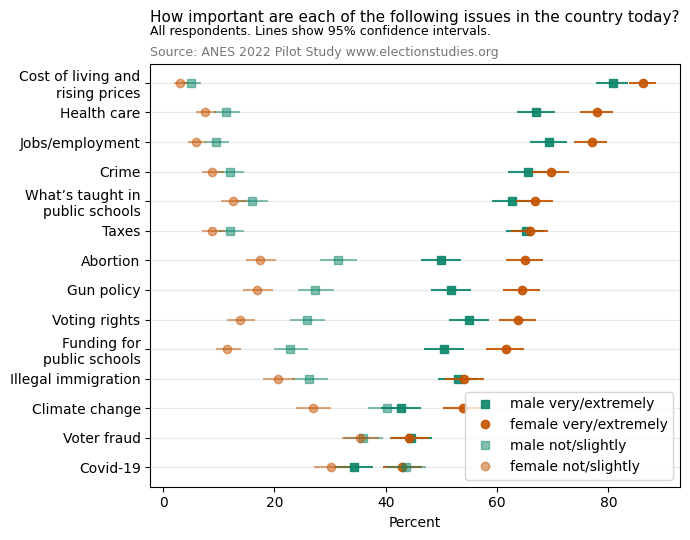

<IPython.core.display.Javascript object>

In [39]:
title = "How important are each of the following issues in the country today?"
subtitle = "All respondents. Lines show 95% confidence intervals."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary, "very/extremely", alpha=0.9)
plot_responses_by_gender(summary, "not/slightly", alpha=0.5)

## Younger people


In [40]:
gender_map = {"male": df_young_male, "female": df_young_female}
summary2 = estimate_gender_map(columns, gender_map, value_map).sort_values(
    by=("female", "very/extremely", "p")
)
summary2

male                        \
                              very/extremely                         
                                           p        low       high   
impstem_covid19                    39.358653  33.924413   45.06963   
impstem_voter_fraud                34.337759  29.123016  39.959811   
impstem_illegal_immigration        34.899302  29.656837  40.534472   
impstem_voting_rights              51.188297  45.472923  56.872769   
impstem_crime                      49.739137  44.041093  55.443965   
impstem_public_school_educ         51.390396  45.672981  57.071654   
impstem_climate                    51.266764  45.550586  56.949998   
impstem_public_school_funding       54.10428   48.36839  59.733435   
impstem_taxes                      55.846181  50.107248  61.433079   
impstem_gun_policy                 54.893918   49.15579  60.504776   
impstem_abortion                   50.731731  45.021306  56.423126   
impstem_health_care                64.882858  59.242819  70.135856   
impstem_jobs                       65.933376  60.317952  71.134438   
impstem_CoL                        70.091721  64.602993  75.057949   

                                                                  \
                              not/slightly                         
                                         p        low       high   
impstem_covid19                  36.085833  30.787472  41.746043   
impstem_voter_fraud              35.240261  29.981364  40.882997   
impstem_illegal_immigration      34.076501  28.874937  39.692169   
impstem_voting_rights             25.71749  21.039246   31.02722   
impstem_crime                    18.469321  14.435431  23.323191   
impstem_public_school_educ        19.19517  15.086981  24.104463   
impstem_climate                  25.487097  20.826315  30.785357   
impstem_public_school_funding    20.279194  16.064478  25.266823   
impstem_taxes                    15.939326  12.184791  20.579635   
impstem_gun_policy               16.583279   12.75446  21.281126   
impstem_abortion                 28.169807  23.316427  33.590899   
impstem_health_care              10.087949   7.133691  14.080152   
impstem_jobs                     14.848477  11.225182  19.385916   
impstem_CoL                       9.550927    6.68432  13.469444   

                                      female                        \
                              very/extremely                         
                                           p        low       high   
impstem_covid19                    37.679589  32.283036  43.400085   
impstem_voter_fraud                38.831829  33.388632  44.568672   
impstem_illegal_immigration        45.177748  39.534585  50.947704   
impstem_voting_rights              53.714704  47.928408  59.402649   
impstem_crime                      55.433467  49.662606  61.061465   
impstem_public_school_educ         56.312264   50.54161  61.916948   
impstem_climate                    56.454135  50.683682  62.054888   
impstem_public_school_funding      58.485796   52.72337  64.025103   
impstem_taxes                       58.69217  52.931102  64.224693   
impstem_gun_policy                  59.38814  53.632397  64.897039   
impstem_abortion                   63.389769  57.687392  68.740085   
impstem_health_care                70.305531  64.792895   75.28427   
impstem_jobs                       71.732809  66.276138  76.618055   
impstem_CoL                        79.528999  74.498177  83.783408   

                                                                  
                              not/slightly                        
                                         p        low       high  
impstem_covid19                  33.700779  28.491052  39.339065  
impstem_voter_fraud              38.853364  33.409327  44.590482  
impstem_illegal_immigration       27.69499  22.848975  33.127475  
impstem_voting_rights            17.613399  13.638329  22.445932  
impstem_crime                   

<IPython.core.display.Javascript object>

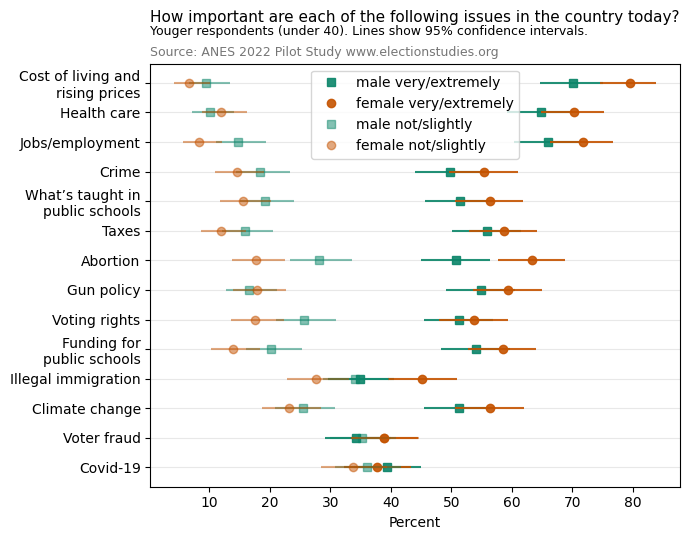

<IPython.core.display.Javascript object>

In [41]:
subtitle = "Youger respondents (under 40). Lines show 95% confidence intervals."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary2, "very/extremely", alpha=0.9)
plot_responses_by_gender(summary2, "not/slightly", alpha=0.5)

## Pairwise compatibility

One way to interpret these results is to pick the ones with the biggest differences and talk about "wow the differences".
But these differences are often used to tell a story along the lines that men and women are becoming more politically incompatible, so I think it would be useful to quantify what we mean by compatible.

For example, if we imagine a speed-dating service that matches random women and men, and compares their responses, we could define a kind of compatibility score and see how often a hypothetical pair would find themselves disagreeing by too much on to many points.

We could calibrate the results by comparing them with male-male and female-female compatibility.

Here's a possible scoring function.
If you and another person assign the same level of importance to an issue, you get 2 points.
If you differ by 1 level, that's 0 points.
Differing by 2 levels costs 1 point, 3 levels costs 2 points, and four levels, which means you are at opposite ends of the range, costs 4 points.

In [42]:
score_map = {0: 2, 1: 0, 2: -1, 3: -2, 4: -4}
score_array = np.array(list(score_map.values()))

<IPython.core.display.Javascript object>

Spot check the first row from each group.

In [43]:
data_male = df_male[columns].replace(-7, np.nan)
data_female = df_female[columns].replace(-7, np.nan)

<IPython.core.display.Javascript object>

In [44]:
np.abs(data_male.iloc[0] - data_female.iloc[0]).replace(score_map).sum()

9.0

<IPython.core.display.Javascript object>

The following function computes the total score across all issues for each pair of people in the two groups.

In [45]:
def pairwise_compatiblity(df1, df2):
    diffs = np.abs(df1.values[:, None, :] - df2.values[None, :, :])

    # replace missing values with 1,
    # which is a little bigger than the mean difference
    nan = np.isnan(diffs)
    diffs[nan] = 1

    return score_array[diffs.astype(int)].sum(axis=2)

<IPython.core.display.Javascript object>

Here's the compatibility array for men and women (and the spot check for the first pair).

In [46]:
compat_mf = pairwise_compatiblity(data_male, data_female)
compat_mf[0, 0]

9

<IPython.core.display.Javascript object>

And here's the level of compatibility, averaged across all male-female pairs 

In [47]:
compat_mf.mean()

-1.9283959936960997

<IPython.core.display.Javascript object>

To put that in context, if you choose two women at random, they would be only slightly more politically compatible.

In [48]:
compat_ff = pairwise_compatiblity(data_female, data_female)
compat_ff.mean()

-0.3409663534923092

<IPython.core.display.Javascript object>

And a random pair of men would be a bit less compatible.

In [49]:
compat_mm = pairwise_compatiblity(data_male, data_male)
compat_mm.mean()

-2.776135594924196

<IPython.core.display.Javascript object>

However, these results vary from one resampling to another, so we would need to report them with error bars.

## Which Party Better Job

This section explores responses to a set of questions based on this schema:

>Please tell us which political party— the [Democrats/Republicans] or the [Republicans/Democrats]—would do a better job handling each of the following issues, or is there no difference.

```
Tabulation: Freq. Numeric Label
1 -7 No Answer
165 -1 inapplicable, legitimate skip
508 1 Democrats
780 2 Republicans
455 3 No difference
```

In [50]:
columns = find_columns(df, "ownstem_")
columns

['ownstem_covid19',
 'ownstem_illegal_immigration',
 'ownstem_jobs',
 'ownstem_CoL',
 'ownstem_climate',
 'ownstem_abortion',
 'ownstem_gun_policy',
 'ownstem_crime',
 'ownstem_taxes',
 'ownstem_health_care',
 'ownstem_voting_rights',
 'ownstem_voter_fraud']

<IPython.core.display.Javascript object>

In [51]:
issue_names = {
    "ownstem_covid19": "Covid-19",
    "ownstem_illegal_immigration": "Illegal immigration",
    "ownstem_jobs": "Jobs/employment",
    "ownstem_CoL": "Cost of living and\nrising prices",
    "ownstem_climate": "Climate change",
    "ownstem_abortion": "Abortion",
    "ownstem_gun_policy": "Gun policy",
    "ownstem_crime": "Crime",
    "ownstem_voting_rights": "Voting rights",
    "ownstem_taxes": "Taxes",
    "ownstem_health_care": "Health care",
    "ownstem_voter_fraud": "Voter fraud",
}

<IPython.core.display.Javascript object>

In [52]:
columns = issue_names.keys()
counts = value_count_frame(df, columns, normalize=True)
counts

,ownstem_covid19,ownstem_illegal_immigration,ownstem_jobs,ownstem_CoL,ownstem_climate,ownstem_abortion,ownstem_gun_policy,ownstem_crime,ownstem_voting_rights,ownstem_taxes,ownstem_health_care,ownstem_voter_fraud
-7.0,0.000000,0.000667,0.000667,0.000667,0.000000,0.000667,0.000667,0.000667,0.000667,0.001333,0.000667,0.000667
1.0,0.380667,0.316667,0.348667,0.320667,0.447333,0.456000,0.400000,0.284000,0.406667,0.339333,0.445333,0.334000
2.0,0.276000,0.435333,0.402667,0.406667,0.220000,0.286000,0.381333,0.422667,0.299333,0.388667,0.279333,0.332000
3.0,0.343333,0.247333,0.248000,0.272000,0.332667,0.257333,0.218000,0.292667,0.293333,0.270667,0.274667,0.333333


<IPython.core.display.Javascript object>

Most people answered all 12 questions, but a few answered fewer.

In [53]:
data = df[columns].replace(-7, np.nan)
count = data.count(axis=1)
value_counts(count)

,counts
values,
6,1
10,1
11,3
12,1495


<IPython.core.display.Javascript object>

In [54]:
value_map = {"Democrats": [1], "Republicans": [2], "No Difference": [3]}
gender_map = dict(male=df_male, female=df_female)
summary3 = estimate_gender_map(columns, gender_map, value_map).sort_values(
    by=("female", "No Difference", "p")
)
summary3

male                                    \
                             Democrats                       Republicans   
                                     p        low       high           p   
ownstem_gun_policy            35.43665   32.05071  38.975116   43.873586   
ownstem_illegal_immigration  27.382597  24.274116  30.727619   48.439088   
ownstem_abortion             42.389153  38.855216  46.002686   30.700238   
ownstem_jobs                 31.966322   28.68702  35.434225   45.715196   
ownstem_CoL                  29.466006  26.272743  32.874328   44.458434   
ownstem_health_care          41.635931  38.114701  45.244635   30.415735   
ownstem_taxes                32.497966  29.200362  35.978724   41.539013   
ownstem_voting_rights        37.103207  33.676696  40.664597   33.634769   
ownstem_crime                23.932646  20.980554  27.157358   48.381397   
ownstem_covid19              35.707468   32.31662  39.247792   29.336793   
ownstem_climate              43.853325  40.297102  47.473832   26.529291   
ownstem_voter_fraud           33.23805  29.916591  36.734981   38.265897   

                                                                            \
                                                  No Difference              
                                   low       high             p        low   
ownstem_gun_policy           40.314544  47.496791     20.689765  17.907871   
ownstem_illegal_immigration  44.833358  52.061144     24.178314  21.214221   
ownstem_abortion             27.464197  34.138122     26.910609  23.822032   
ownstem_jobs                 42.135187  49.340016     22.318483  19.448782   
ownstem_CoL                  40.891385  48.083523      26.07556  23.021219   
ownstem_health_care          27.189815  33.846473     27.948334  24.816589   
ownstem_taxes                 38.01841  45.148159     25.963021  22.914895   
ownstem_voting_rights        30.302781  37.137909     29.262024  26.078691   
ownstem_crime                  44.7761  52.003622     27.685957  24.564922   
ownstem_covid19              26.150624  32.739065     34.955738  31.585412   
ownstem_climate              23.457129  29.846918     29.617383  26.420666   
ownstem_voter_fraud          34.810413  41.844219     28.496052  25.340919   

                                           female                        \
                                        Democrats                         
                                  high          p        low       high   
ownstem_gun_policy           23.778635  42.522998  39.074977  46.045327   
ownstem_illegal_immigration  27.412459  34.210331  30.942656  37.635023   
ownstem_abortion             30.240663  45.737356  42.245644  49.271457   
ownstem_jobs                 25.477686  35.915472  32.601871  39.369134   
ownstem_CoL                   29.38047  33.554921  30.307122  36.966156   
ownstem_health_care          31.310703  45.344173  41.856886  48.877759   
ownstem_taxes                29.262689  34.648364  31.367519   38.08196   
ownstem_voting_rights        32.662242  41.455804  38.024208  44.972367   
ownstem_crime                31.040361  31.500431  28.315644  34.869184   
ownstem_covid19              38.483403  39.801321  36.401119   43.30288   
ownstem_climate              33.027268  45.247313  41.762201  48.779659   
ownstem_voter_fraud          31.876298  32.733232  29.510149  36.127919   

                                                                             \
                            Republicans                       No Difference   
                                      p        low       high             p   
ownstem_gun_policy              33.0498  29.817059  36.450996     24.427203   
ownstem_illegal_immigration   39.019361  35.633919  42.513998     26.770308   
ownstem_abortion              26.392007  23.399243  29.619536     27.870638   
ownstem_jobs                  36.016168       32.7  39.471395     28.068361   
ownstem_CoL                   38.227078  34

<IPython.core.display.Javascript object>

In [55]:
index = summary3.index

<IPython.core.display.Javascript object>

For every issue, men are more likely to say that the Republicans handle it better.

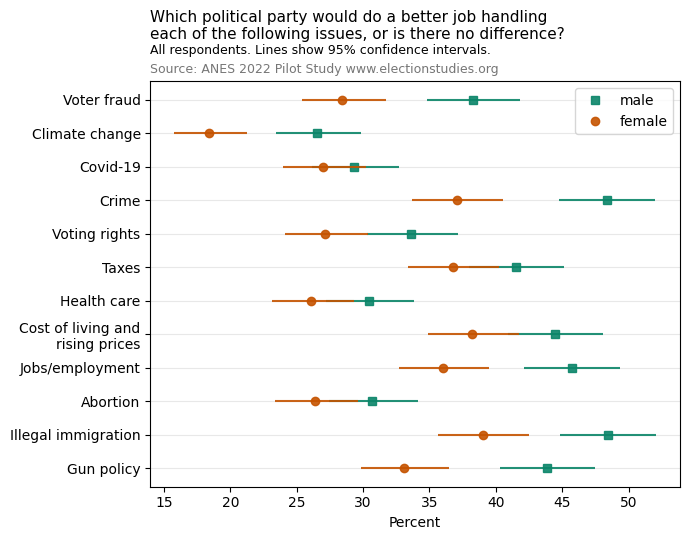

<IPython.core.display.Javascript object>

In [56]:
title = """Which political party would do a better job handling 
each of the following issues, or is there no difference?"""
subtitle = "All respondents. Lines show 95% confidence intervals."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary3, "Republicans", label_response=False, alpha=0.9)

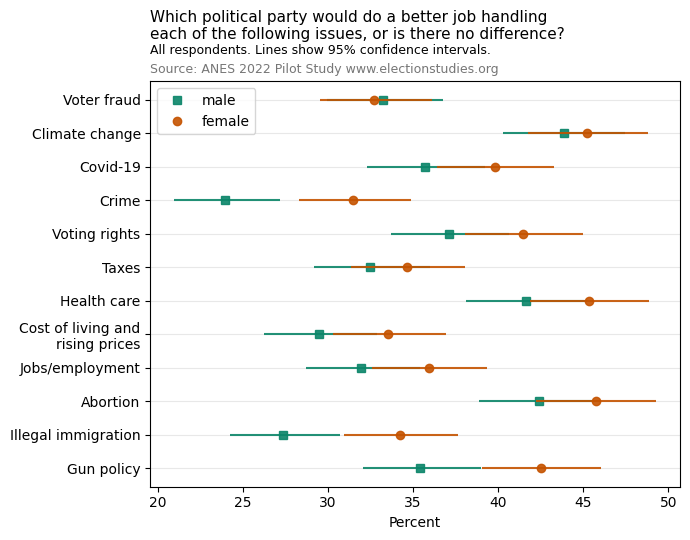

<IPython.core.display.Javascript object>

In [57]:
plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary3, "Democrats", label_response=False, alpha=0.9)

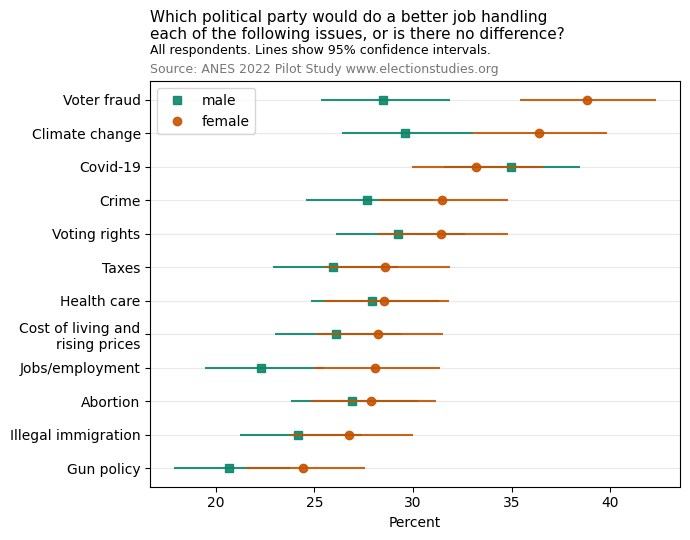

<IPython.core.display.Javascript object>

In [58]:
plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary3, "No Difference", label_response=False, alpha=0.9)

And here are the weighted estimates

In [59]:
estimate_proportion(df_male["ownstem_abortion"] == 3, df_male["weight"])

(0.2691060923425381, 0.2382203195873818, 0.30240662676295815)

<IPython.core.display.Javascript object>

In [60]:
estimate_proportion(df_female["ownstem_abortion"] == 3, df_female["weight"])

(0.2785364460420787, 0.24801762769175117, 0.3112562339085232)

<IPython.core.display.Javascript object>

### Subset the people with a preference

In [61]:
def make_subset(df, columns):
    subset = df.copy()
    for column in columns:
        subset[column] = subset[column].replace(3, np.nan)
    return subset

<IPython.core.display.Javascript object>

In [62]:
subset_male = make_subset(df_male, columns)
subset_female = make_subset(df_female, columns)

<IPython.core.display.Javascript object>

In [63]:
subset_young_male = make_subset(df_young_male, columns)
subset_young_female = make_subset(df_young_female, columns)

<IPython.core.display.Javascript object>

In [64]:
df_male["ownstem_illegal_immigration"].value_counts()

ownstem_illegal_immigration
2.0    348
1.0    191
3.0    152
Name: count, dtype: int64

<IPython.core.display.Javascript object>

In [65]:
subset_male["ownstem_illegal_immigration"].value_counts(normalize=True)

ownstem_illegal_immigration
2.0    0.64564
1.0    0.35436
Name: proportion, dtype: float64

<IPython.core.display.Javascript object>

In [66]:
estimate_columns(subset_male, columns, [2])

,p,low,high
ownstem_covid19,45.102816,40.686583,49.597569
ownstem_illegal_immigration,63.885534,59.803132,67.776727
ownstem_jobs,58.849514,54.755092,62.824974
ownstem_CoL,60.140373,55.951032,64.186315
ownstem_climate,37.69296,33.610619,41.957772
ownstem_abortion,42.003686,37.889637,46.231934
ownstem_gun_policy,55.318945,51.24666,59.321087
ownstem_crime,66.904567,62.783267,70.781874
ownstem_voting_rights,47.54839,43.277321,51.855627
ownstem_taxes,56.105765,51.894403,60.230982


<IPython.core.display.Javascript object>

In [67]:
value_map = {"Democrats": [1], "Republicans": [2]}
estimate_value_map(subset_male, columns, value_map)

Democrats                       Republicans  \
                                     p        low       high           p   
ownstem_covid19              54.897184  50.402431  59.313417   45.102816   
ownstem_illegal_immigration  36.114466  32.223273  40.196868   63.885534   
ownstem_jobs                 41.150486  37.175026  45.244908   58.849514   
ownstem_CoL                  39.859627  35.813685  44.048968   60.140373   
ownstem_climate               62.30704  58.042228  66.389381    37.69296   
ownstem_abortion             57.996314  53.768066  62.110363   42.003686   
ownstem_gun_policy           44.681055  40.678913   48.75334   55.318945   
ownstem_crime                33.095433  29.218126  37.216733   66.904567   
ownstem_voting_rights         52.45161  48.144373  56.722679    47.54839   
ownstem_taxes                43.894235  39.769018  48.105597   56.105765   
ownstem_health_care          57.786216  53.526117  61.933527   42.213784   
ownstem_voter_fraud          46.484217  42.246955  50.772845   53.515783   

                                                   
                                   low       high  
ownstem_covid19              40.686583  49.597569  
ownstem_illegal_immigration  59.803132  67.776727  
ownstem_jobs                 54.755092  62.824974  
ownstem_CoL                  55.951032  64.186315  
ownstem_climate              33.610619  41.957772  
ownstem_abortion             37.889637  46.231934  
ownstem_gun_policy            51.24666  59.321087  
ownstem_crime                62.783267  70.781874  
ownstem_voting_rights        43.277321  51.855627  
ownstem_taxes                51.894403  60.230982  
ownstem_health_care          38.066473  46.473883  
ownstem_voter_fraud          49.227155  57.753045

<IPython.core.display.Javascript object>

In [68]:
gender_map = dict(male=subset_male, female=subset_female)
summary4 = estimate_gender_map(columns, gender_map, value_map).sort_values(
    by=("male", "Republicans", "p")
)
summary4

male                                    \
                             Democrats                       Republicans   
                                     p        low       high           p   
ownstem_climate               62.30704  58.042228  66.389381    37.69296   
ownstem_abortion             57.996314  53.768066  62.110363   42.003686   
ownstem_health_care          57.786216  53.526117  61.933527   42.213784   
ownstem_covid19              54.897184  50.402431  59.313417   45.102816   
ownstem_voting_rights         52.45161  48.144373  56.722679    47.54839   
ownstem_voter_fraud          46.484217  42.246955  50.772845   53.515783   
ownstem_gun_policy           44.681055  40.678913   48.75334   55.318945   
ownstem_taxes                43.894235  39.769018  48.105597   56.105765   
ownstem_jobs                 41.150486  37.175026  45.244908   58.849514   
ownstem_CoL                  39.859627  35.813685  44.048968   60.140373   
ownstem_illegal_immigration  36.114466  32.223273  40.196868   63.885534   
ownstem_crime                33.095433  29.218126  37.216733   66.904567   

                                                      female             \
                                                   Democrats              
                                   low       high          p        low   
ownstem_climate              33.610619  41.957772  71.124815  66.957336   
ownstem_abortion             37.889637  46.231934  63.410176  59.321454   
ownstem_health_care          38.066473  46.473883  63.468591  59.360917   
ownstem_covid19              40.686583  49.597569  59.571886    55.2732   
ownstem_voting_rights        43.277321  51.855627  60.457863   56.22271   
ownstem_voter_fraud          49.227155  57.753045  53.506413  48.989805   
ownstem_gun_policy            51.24666  59.321087  56.267598  52.207034   
ownstem_taxes                51.894403  60.230982  48.525844  44.368426   
ownstem_jobs                 54.755092  62.824974  49.930006  45.777494   
ownstem_CoL                  55.951032  64.186315  46.745593  42.620793   
ownstem_illegal_immigration  59.803132  67.776727  46.716475  42.631276   
ownstem_crime                62.783267  70.781874  45.955034  41.744555   

                                                                          
                                       Republicans                        
                                  high           p        low       high  
ownstem_climate              74.963214   28.875185  25.036786  33.042664  
ownstem_abortion              67.31437   36.589824   32.68563  40.678546  
ownstem_health_care          67.389166   36.531409  32.610834  40.639083  
ownstem_covid19              63.728542   40.428114  36.271458    44.7268  
ownstem_voting_rights        64.541696   39.542137  35.458304   43.77729  
ownstem_voter_fraud          57.966238   46.493587  42.033762  51.010195  
ownstem_gun_policy           60.245871   43.732402  39.754129  47.792966  
ownstem_taxes                52.703765   51.474156  47.296235  55.631574  
ownstem_jobs                 54.083483   50.069994  45.916517  54.222506  
ownstem_CoL                  50.915362   53.254407  49.084638  57.379207  
ownstem_illegal_immigration  50.846182   53.283525  49.153818  57.368724  
ownstem_crime                50.224062   54.044966  49.775938  58.255445

<IPython.core.display.Javascript object>

In [69]:
index = summary4.index

<IPython.core.display.Javascript object>

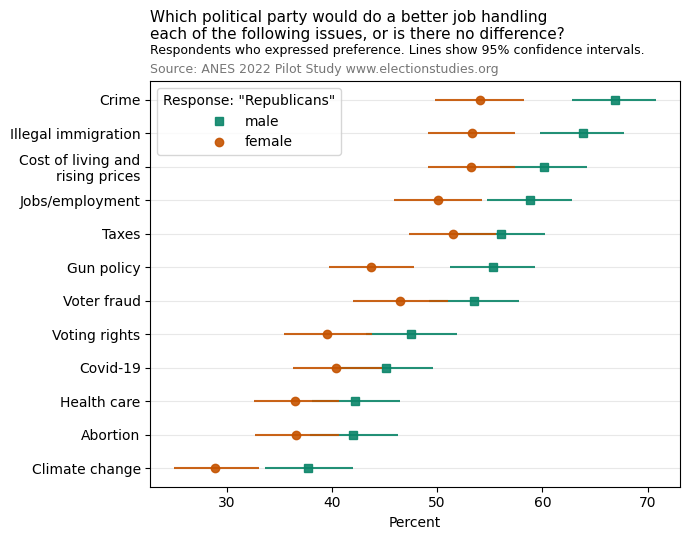

<IPython.core.display.Javascript object>

In [70]:
title = """Which political party would do a better job handling 
each of the following issues, or is there no difference?"""
subtitle = "Respondents who expressed preference. Lines show 95% confidence intervals."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary4, "Republicans", label_response=False, alpha=0.9)
plt.legend(title='Response: "Republicans"')

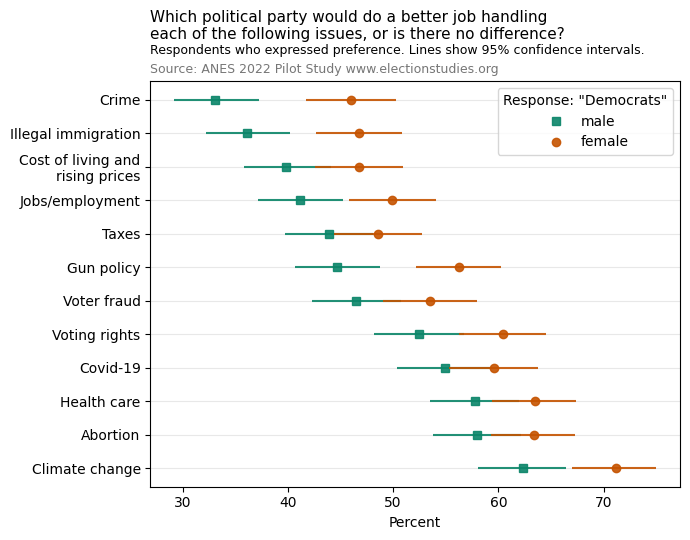

<IPython.core.display.Javascript object>

In [71]:
title = """Which political party would do a better job handling 
each of the following issues, or is there no difference?"""
subtitle = "Respondents who expressed preference. Lines show 95% confidence intervals."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary4, "Democrats", label_response=False, alpha=0.9)
plt.legend(title='Response: "Democrats"')

In [72]:
gender_map = dict(male=subset_young_male, female=subset_young_female)
summary5 = estimate_gender_map(columns, gender_map, value_map).sort_values(
    by=("male", "Republicans", "p")
)
summary5

male                                    \
                             Democrats                       Republicans   
                                     p        low       high           p   
ownstem_climate              73.145422   66.76431   78.69239   26.854578   
ownstem_abortion             71.817427  65.182935  77.621724   28.182573   
ownstem_health_care          67.056036  60.238059  73.224582   32.943964   
ownstem_voting_rights        66.207288  59.105579  72.646468   33.792712   
ownstem_covid19              63.555658  56.256284  70.280476   36.444342   
ownstem_voter_fraud          62.905624  55.671541   69.60373   37.094376   
ownstem_taxes                56.412305  49.217094  63.347265   43.587695   
ownstem_gun_policy           54.797238  47.890364  61.524145   45.202762   
ownstem_jobs                  53.62007  46.705802  60.397903    46.37993   
ownstem_illegal_immigration  52.730089  45.753955  59.601219   47.269911   
ownstem_CoL                  52.309236  45.213607  59.312862   47.690764   
ownstem_crime                47.002471  39.884777  54.244216   52.997529   

                                                      female             \
                                                   Democrats              
                                   low       high          p        low   
ownstem_climate               21.30761   33.23569  75.741926  68.499837   
ownstem_abortion             22.378276  34.817065  66.258608  59.216125   
ownstem_health_care          26.775418  39.761941   67.40563  60.153741   
ownstem_voting_rights        27.353532  40.894421  66.217346  58.645111   
ownstem_covid19              29.719524  43.743716  59.420845  52.120192   
ownstem_voter_fraud           30.39627  44.328459  59.621121  51.442503   
ownstem_taxes                36.652735  50.782906  49.793246  42.368042   
ownstem_gun_policy           38.475855  52.109636  60.178709  53.126909   
ownstem_jobs                 39.602097  53.294198  52.240149  45.032698   
ownstem_illegal_immigration  40.398781  54.246045  52.534193  45.171558   
ownstem_CoL                  40.687138  54.786393  47.322181  39.897574   
ownstem_crime                45.755784  60.115223  51.562429  44.181138   

                                                                          
                                       Republicans                        
                                  high           p        low       high  
ownstem_climate              81.762309   24.258074  18.237691  31.500163  
ownstem_abortion             72.646744   33.741392  27.353256  40.783875  
ownstem_health_care          73.910132    32.59437  26.089868  39.846259  
ownstem_voting_rights        73.040463   33.782654  26.959537  41.354889  
ownstem_covid19              66.327488   40.579155  33.672512  47.879808  
ownstem_voter_fraud          67.297904   40.378879  32.702096  48.557497  
ownstem_taxes                57.227581   50.206754  42.772419  57.631958  
ownstem_gun_policy           66.831945   39.821291  33.168055  46.873091  
ownstem_jobs                 59.355508   47.759851  40.644492  54.967302  
ownstem_illegal_immigration   59.78827   47.465807   40.21173  54.828442  
ownstem_CoL                   54.86714   52.677819   45.13286  60.102426  
ownstem_crime                58.876176   48.437571  41.123824  55.818862

<IPython.core.display.Javascript object>

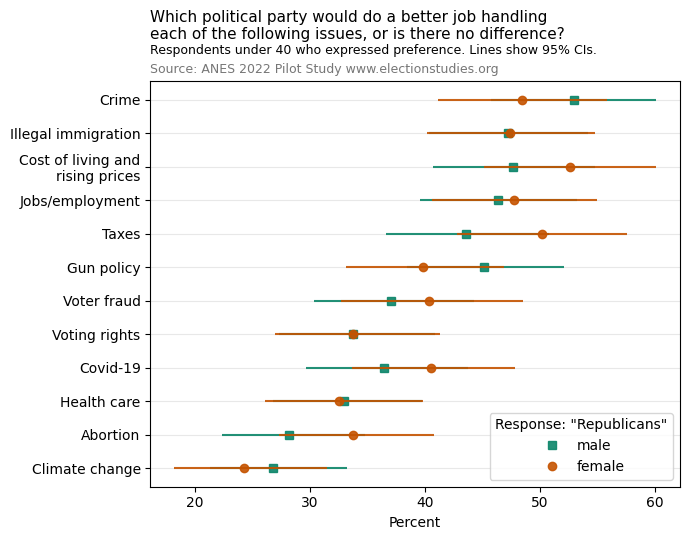

<IPython.core.display.Javascript object>

In [73]:
title = """Which political party would do a better job handling 
each of the following issues, or is there no difference?"""
subtitle = "Respondents under 40 who expressed preference. Lines show 95% CIs."

plt.figure(figsize=(7, 5.5))
make_title(title, subtitle)
plot_responses_by_gender(summary5, "Republicans", label_response=False, alpha=0.9)
plt.legend(title='Response: "Republicans"', loc="lower right")

## Alignment with party


For each respondents, we add up the fraction of responses in each of the three categories, and the party they were more favorable toward. 

In [74]:
df["dem"] = (data == 1).sum(axis=1) / count
df["rep"] = (data == 2).sum(axis=1) / count
df["no_diff"] = (data == 3).sum(axis=1) / count

df["pref"] = "no diff"
df.loc[df["dem"] > df["rep"], "pref"] = "dem"
df.loc[df["rep"] > df["dem"], "pref"] = "rep"

df[["dem", "rep", "no_diff", "pref"]].head()

,dem,rep,no_diff,pref
0,0.000000,0.333333,0.666667,rep
1,0.000000,1.000000,0.000000,rep
2,0.166667,0.416667,0.416667,rep
3,1.000000,0.000000,0.000000,dem
4,1.000000,0.000000,0.000000,dem


<IPython.core.display.Javascript object>

In [75]:
value_counts(df["pref"])

,counts
values,
dem,672
no diff,192
rep,636


<IPython.core.display.Javascript object>

People who identify as Democrats are more likely to think the Democratic party handles these issues better, and people who identify as Republican are more likely to think the Republican party does -- but there are some exceptions in both directions, which might reflect data quality problems.

In [76]:
df["pid"] = df["pid3"].replace([-7, 4, 5], np.nan)

<IPython.core.display.Javascript object>

In [77]:
pd.crosstab(df["pid"], df["pref"])

pref,dem,no diff,rep
pid,,,
1.0,418,25,34
2.0,23,17,359
3.0,158,78,176


<IPython.core.display.Javascript object>

Here's the distribution of partisanship.

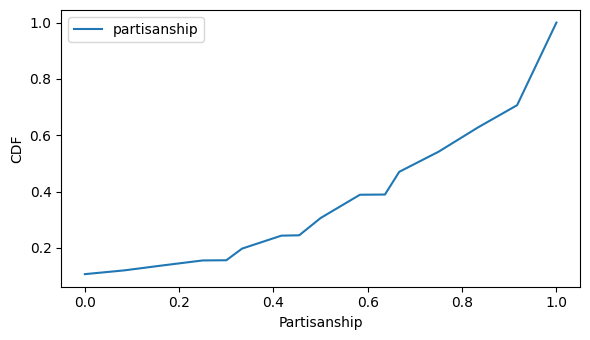

<IPython.core.display.Javascript object>

In [78]:
from empiricaldist import Cdf

df["partisanship"] = df[["dem", "rep"]].max(axis=1)
Cdf.from_seq(df["partisanship"]).plot(label="partisanship")
decorate(xlabel="Partisanship", ylabel="CDF")

A score of 0 means the respondent said "no difference" to every questions. A score of 1 means they said that one party or the other handles every issue better.

Men are more partisan than women.

In [79]:
df.groupby("gender")["partisanship"].mean()

gender
1.0    0.685684
2.0    0.650129
Name: partisanship, dtype: float64

<IPython.core.display.Javascript object>

If we break it down by gender and party identification, republicans are more partisan than democrats, independent/other are less partisan than both.


In [80]:
tab = df.pivot_table(
    index="gender",
    columns="pid",
    values="partisanship",
    aggfunc="mean",
    margins=True,
)
tab.columns = ["dem", "rep", "ind/other", "all"]
tab.index = ["male", "female", "all"]
tab

,dem,rep,ind/other,all
male,0.776092,0.776456,0.576923,0.703692
female,0.771572,0.745994,0.530977,0.696280
all,0.773420,0.760576,0.555623,0.699773


<IPython.core.display.Javascript object>

## Campaign interest

Here are responses to "Some people don’t pay much attention to political campaigns.
How about you? Would you say that you have been [very much interested, somewhat
interested or not much interested/ not much interested, somewhat interested or very
much interested] in the political campaigns so far this year?"

```
1. Very much interested
2. Somewhat interested
3. Not much interested
```

`newsint` is one of the variables merged from profile info, so the question isn't in the code book. But here are the answers.

```
2 ‐7 No Answer
723 1 Most of the time
429 2 Some of the time
219 3 Only now and then
152 4 Hardly at all
60 7 Don't know
```

In [81]:
value_counts(df["follow"])

,counts
values,
1.0,720
2.0,440
3.0,208
4.0,132


<IPython.core.display.Javascript object>

In [82]:
estimate_proportion(df["follow"] == 1, df["weight"])

(0.4679693760408319, 0.4428322986075227, 0.4932700932761678)

<IPython.core.display.Javascript object>

In [83]:
estimate_proportion(df_male["follow"] == 1, df_male["weight"])

(0.5522369004242446, 0.5160041088723853, 0.5879233819156243)

<IPython.core.display.Javascript object>

In [84]:
estimate_proportion(df_female["follow"] == 1, df_female["weight"])

(0.38791285777930823, 0.35411628006379225, 0.42282339026872484)

<IPython.core.display.Javascript object>

In [85]:
columns = ["follow", "newsint"]
gender_map = dict(male=df_male, female=df_female)
value_map = {"Very much": [1], "Somewhat": [2], "Not much": [3]}
summary6 = estimate_gender_map(columns, gender_map, value_map)
summary6

male                                                         \
         Very much                         Somewhat                         
                 p        low       high          p        low       high   
follow    55.22369  51.600411  58.792338  26.213424  23.155088  29.520527   
newsint  48.629227  45.022101  52.250689  25.981234  22.933196  29.280468   

                                             female                        \
          Not much                        Very much                         
                 p        low       high          p        low       high   
follow   11.414838   9.308282  13.924929  38.791286  35.411628  42.282339   
newsint   12.69611  10.475779  15.306578   37.06743    33.7215  40.542275   

                                                                           
          Somewhat                         Not much                        
                 p        low       high          p        low       high  
follow   33.394746  30.151676  36.802844  16.810728  14.334361   19.61694  
newsint  29.307505  26.195558  32.625718  16.996486  14.504207  19.817748

<IPython.core.display.Javascript object>

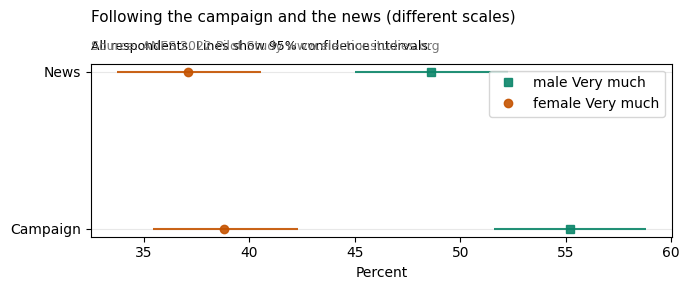

<IPython.core.display.Javascript object>

In [86]:
title = "Following the campaign and the news (different scales)"
subtitle = "All respondents. Lines show 95% confidence intervals."

plt.figure(figsize=(7, 3))
make_title(title, subtitle)
index = summary6.index
issue_names = {"follow": "Campaign", "newsint": "News"}
plot_responses_by_gender(summary6, "Very much", alpha=0.9)

People who follow more closely are more partisan. The arrow of causation could go both ways there.

In [87]:
pd.crosstab(df["gender"], df["follow"], normalize="index")

follow,1.0,2.0,3.0,4.0
gender,,,,
1.0,0.584660,0.254703,0.105644,0.054993
2.0,0.390606,0.326329,0.166873,0.116193


<IPython.core.display.Javascript object>

In [88]:
tab = df.pivot_table(
    index="gender",
    columns="follow",
    values="partisanship",
    aggfunc="mean",
    margins=True,
)
tab.columns = ["most", "some", "now and then", "hardly", "all"]
tab.index = ["male", "female", "all"]
tab

,most,some,now and then,hardly,all
male,0.785197,0.620076,0.478311,0.329944,0.685684
female,0.795886,0.637770,0.538272,0.355496,0.650129
all,0.789888,0.630692,0.517228,0.348140,0.666508


<IPython.core.display.Javascript object>

## Regression models

To put it all together, we'll run some regressions with partisanship as the dependent variable.

In [89]:
from statsmodels.iolib.table import SimpleTable


def display_summary(result):
    """Prints summary statistics from a regression model.

    result: RegressionResults object
    """
    params = result.summary().tables[1]
    display(params)

    if hasattr(result, "rsquared"):
        row = ["R-squared:", f"{result.rsquared:0.4}"]
    elif hasattr(result, "prsquared"):
        row = ["Pseudo R-squared:", f"{result.prsquared:0.4}"]
    else:
        return
    table = SimpleTable([row])
    display(table)

<IPython.core.display.Javascript object>

Women are less partisan.

In [90]:
import statsmodels.formula.api as smf

model = smf.ols('partisanship ~ C(gender)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.6857,0.013,54.441,0.000,0.661,0.710
C(gender)[T.2.0],-0.0356,0.017,-2.073,0.038,-0.069,-0.002


R-squared:,0.002861


<IPython.core.display.Javascript object>

Controlling for gender, republicans are (still) more partisan, independent/other are less.

In [91]:
import statsmodels.formula.api as smf

model = smf.ols('partisanship ~ C(gender) + C(pid)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.7888,0.017,47.533,0.000,0.756,0.821
C(gender)[T.2.0],-0.0260,0.016,-1.580,0.114,-0.058,0.006
C(pid)[T.2.0],-0.0147,0.020,-0.735,0.462,-0.054,0.024
C(pid)[T.3.0],-0.2211,0.020,-11.140,0.000,-0.260,-0.182


R-squared:,0.104


<IPython.core.display.Javascript object>

Controlling for level of interest in the campaign, the gender gap is cut by more than half.

I'd suggest that interest level is a mediator here -- part of the reason men are more partisan is that they follow the campaign more closely.

In [92]:
model = smf.ols('partisanship ~ C(gender) + C(pid) + C(follow)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.8501,0.017,51.139,0.000,0.818,0.883
C(gender)[T.2.0],0.0153,0.016,0.972,0.331,-0.016,0.046
C(pid)[T.2.0],-0.0079,0.019,-0.420,0.675,-0.045,0.029
C(pid)[T.3.0],-0.1945,0.019,-10.392,0.000,-0.231,-0.158
C(follow)[T.2.0],-0.1385,0.018,-7.716,0.000,-0.174,-0.103
C(follow)[T.3.0],-0.2308,0.024,-9.746,0.000,-0.277,-0.184
C(follow)[T.4.0],-0.3270,0.032,-10.244,0.000,-0.390,-0.264


R-squared:,0.2158


<IPython.core.display.Javascript object>

## Regressions

Let's run some regressions with number of "no difference" as the dependent variable.

In [93]:
df["y"] = (df[columns] == 3).sum(axis=1)
df.groupby("gender")["y"].mean()

gender
1.0    0.217077
2.0    0.334981
Name: y, dtype: float64

<IPython.core.display.Javascript object>

The difference in means is 1.33

In [94]:
model = smf.ols('y ~ C(gender)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2171,0.022,9.688,0.000,0.173,0.261
C(gender)[T.2.0],0.1179,0.031,3.865,0.000,0.058,0.178


R-squared:,0.009871


<IPython.core.display.Javascript object>

Part of that is "explained" by party id: women are less likely to identify as Republican, and  Republicans are less likely to say "no difference".

In [95]:
model = smf.ols('y ~ C(gender) + C(pid)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1736,0.033,5.191,0.000,0.108,0.239
C(gender)[T.2.0],0.1284,0.033,3.869,0.000,0.063,0.194
C(pid)[T.2.0],0.0277,0.040,0.689,0.491,-0.051,0.106
C(pid)[T.3.0],0.0922,0.040,2.304,0.021,0.014,0.171


R-squared:,0.01444


<IPython.core.display.Javascript object>

In [96]:
model = smf.ols('y ~ C(gender) + C(pid) + C(follow)', data=df).fit()
display_summary(model)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0259,0.018,1.419,0.156,-0.010,0.062
C(gender)[T.2.0],0.0067,0.017,0.391,0.696,-0.027,0.041
C(pid)[T.2.0],-0.0194,0.021,-0.947,0.344,-0.060,0.021
C(pid)[T.3.0],-0.0249,0.021,-1.212,0.226,-0.065,0.015
C(follow)[T.2.0],0.1513,0.020,7.678,0.000,0.113,0.190
C(follow)[T.3.0],1.5426,0.026,59.354,0.000,1.492,1.594
C(follow)[T.4.0],0.1361,0.035,3.886,0.000,0.067,0.205


R-squared:,0.744


<IPython.core.display.Javascript object>

## Group Ratings

This section explores reponses to questions that follow this schema:

> We would like to get your feelings toward some of our political leaders
and other people who are in the news these days. We will show the name of a person
and we’d like you to rate that person using something we call the feeling thermometer.
Ratings between 50 degrees and 100 degrees mean that you feel favorable and warm
toward the person. Ratings between 0 degrees and 50 degrees mean that you don’t feel
favorable toward the person and that you don’t care too much for that person. You
would rate the person at the 50 degree mark if you don’t feel particularly warm or cold
toward the person.
If we come to a person whose name you don’t recognize, you don’t need to rate that
person. Just click ’Next’ and we’ll move on to the next one.

In [97]:
columns = find_columns(df, "ft")
columns

['ftblack1',
 'ftblack2',
 'ftwhite1',
 'ftwhite2',
 'fthisp',
 'ftasian',
 'ftfbi',
 'ftscotus',
 'fttrump',
 'ftbiden',
 'ftdem',
 'ftrep',
 'ftteach',
 'ftfem',
 'ftnfem',
 'ftjourn',
 'ftmen',
 'ftwomen',
 'fttrans']

<IPython.core.display.Javascript object>

In [98]:
df[columns].replace(-7, np.nan).describe()

,ftblack1,ftblack2,ftwhite1,ftwhite2,fthisp,ftasian,ftfbi,ftscotus,fttrump,ftbiden,ftdem,ftrep,ftteach,ftfem,ftnfem,ftjourn,ftmen,ftwomen,fttrans
count,1498.000000,1500.000000,1499.000000,1500.000000,1499.000000,1498.000000,1500.000000,1500.000000,1499.000000,1500.000000,1500.000000,1498.000000,1499.000000,1498.000000,1488.000000,1499.000000,1499.000000,1499.000000,1495.000000
mean,35.855140,35.050000,34.961975,34.351333,70.767845,72.255674,52.078667,50.272667,39.346231,43.930667,48.722667,46.716288,72.134757,51.845794,51.479839,49.139426,69.464977,78.989326,51.814047
std,40.200679,40.432001,39.137112,39.682478,23.819711,23.631115,29.975292,28.935085,37.338878,35.715677,33.734440,32.170206,25.470536,29.661634,27.560722,28.607396,22.924368,21.836781,31.925012
min,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,50.500000,53.000000,30.000000,30.000000,1.000000,5.000000,15.000000,15.000000,54.000000,30.000000,35.000000,26.500000,51.000000,65.000000,25.500000
50%,4.500000,-1.000000,7.000000,-1.000000,74.000000,76.000000,54.000000,50.000000,34.000000,46.500000,50.000000,50.000000,79.000000,50.000000,50.000000,50.000000,71.000000,85.000000,50.000000
75%,75.000000,77.000000,72.500000,74.000000,91.000000,93.000000,75.000000,73.000000,73.000000,76.000000,80.000000,75.000000,94.000000,75.000000,71.000000,71.000000,88.000000,100.000000,78.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


<IPython.core.display.Javascript object>

In [99]:
df_male = df.query("gender == 1").replace(-7, np.nan)
df_female = df.query("gender == 2").replace(-7, np.nan)
len(df_male), len(df_female)

(691, 809)

<IPython.core.display.Javascript object>

In [100]:
d = dict(male=df_male[columns].mean(), female=df_female[columns].mean())
ratings_df = pd.DataFrame(d).sort_values(by="female")
ratings_df

,male,female
ftwhite2,34.709117,34.045735
ftwhite1,34.558611,35.306931
ftblack2,34.120116,35.844252
fttrump,43.282200,35.980198
ftblack1,34.470333,37.040892
ftrep,47.956585,45.654275
ftbiden,39.697540,47.546354
ftscotus,52.714906,48.186650
ftnfem,55.132847,48.363636
ftjourn,45.261939,52.455446


<IPython.core.display.Javascript object>

In [101]:
def plot_ratings(summary, names):
    plt.hlines(
        names,
        summary["male"],
        summary["female"],
        color="gray",
        alpha=0.2,
    )
    plt.plot(summary['male'], names, 's', color=aibm_green, label='male')
    plt.plot(summary['female'], names, 'o', color=aibm_orange, label='female')


<IPython.core.display.Javascript object>

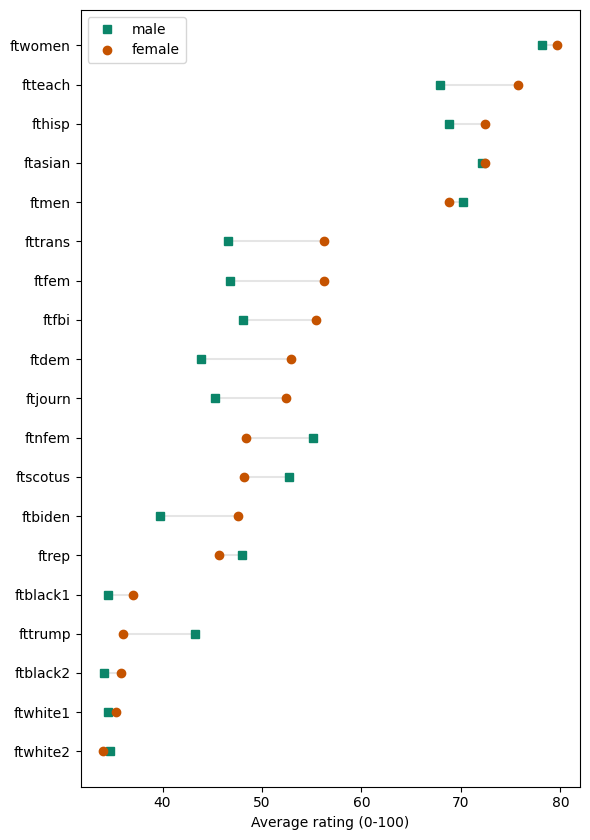

<IPython.core.display.Javascript object>

In [102]:
plt.figure(figsize=(6, 8.5))
names = ratings_df.index
plot_ratings(ratings_df, names)
decorate(xlabel="Average rating (0-100)")

## Look for variables with large gender gaps

This section and the next contain two methods for identifying questions with large gender gaps, without bothering to decode the responses.

Method 1 looks for variables where there's a big difference in the means, but it might not be reliable because a lot of variables are encoded in a way where the mean is not meaningful (or it's misleading).
But it's a way to find candidates.

Method 2 finds the most common response for each questions and looks at the differences in proportions of that response. It is more robust in the sense that it doesn't depend on the meaning of the responses, but it might miss differences in the less common responses.

In [103]:
def compute_diff_means(col, flag):
    male = df_male[col].dropna()
    try:
        male = male.where(male >= 0, np.nan)
    except TypeError:
        return np.nan

    female = df_female[col].dropna()
    female = female.where(female >= 0, np.nan)

    if male.count() == 0 or female.count() == 0:
        return np.nan

    m1, m2 = male.mean(), female.mean()
    avg = (m1 + m2) / 2
    return (m1 - m2) / avg

<IPython.core.display.Javascript object>

In [104]:
df_male = df.query("gender == 1")
df_female = df.query("gender == 2")
len(df_male), len(df_female)

(691, 809)

<IPython.core.display.Javascript object>

In [105]:
df_male.dtypes

version            object
caseid            float64
weight            float64
weight_spss       float64
abortion_treat    float64
                   ...   
no_diff           float64
pref               object
pid               float64
partisanship      float64
y                   int64
Length: 585, dtype: object

<IPython.core.display.Javascript object>

In [106]:
candidate_cols = [
    col for col in df.columns if not col.endswith("timing") and not col.endswith("skp")
]

<IPython.core.display.Javascript object>

In [107]:
res = []
for col in candidate_cols:
    diff1 = compute_diff_means(col, True)
    diff2 = compute_diff_means(col, False)
    res.append((col, diff1, diff2))

<IPython.core.display.Javascript object>

In [108]:
columns = ["varname", "diff1", "diff2"]
diff_df = pd.DataFrame(res, columns=columns).dropna()

<IPython.core.display.Javascript object>

In [109]:
diff1 = diff_df["diff1"]
diff2 = diff_df["diff2"]
diff_df["absdiff"] = np.maximum(diff_df["diff1"].abs(), diff_df["diff2"].abs())

<IPython.core.display.Javascript object>

In [110]:
candidates = diff_df.sort_values(by="absdiff", ascending=False)
candidates.index = candidates["varname"]
candidates = candidates.drop(columns=["varname"]) * 100
candidates.head(50)

,diff1,diff2,absdiff
varname,,,
gender,-66.666667,-66.666667,66.666667
libcon,-44.779918,-44.779918,44.779918
y,-42.714615,-42.714615,42.714615
impnhpiid,-42.424242,-42.424242,42.424242
rep,26.960848,26.960848,26.960848
abafraid,-25.315234,-25.315234,25.315234
aboutraged,-23.769710,-23.769710,23.769710
abworry,-22.478013,-22.478013,22.478013
abangry,-22.407260,-22.407260,22.407260


<IPython.core.display.Javascript object>

In [111]:
candidates.to_csv("anes_2024_candidates_redfd.csv")

<IPython.core.display.Javascript object>

If you find a candidate, you can look more closely with `compare_responses`.

In [112]:
def compare_responses(varname):
    d = dict(
        male=value_counts(df_male[varname], normalize=True)["counts"],
        female=value_counts(df_female[varname], normalize=True)["counts"],
    )
    summary = pd.DataFrame(d)
    summary["diff"] = summary["male"] - summary["female"]
    summary["absdiff"] = summary["diff"].abs()
    return summary

<IPython.core.display.Javascript object>

In [113]:
compare_responses("pew_prayer") * 100

,male,female,diff,absdiff
values,,,,
1.0,24.746744,28.182942,-3.436198,3.436198
2.0,13.748191,16.069221,-2.321030,2.321030
3.0,11.722142,10.135970,1.586171,1.586171
4.0,3.617945,3.337454,0.280491,0.280491
5.0,5.933430,6.304079,-0.370649,0.370649
6.0,15.774240,14.338690,1.435550,1.435550
7.0,21.418234,16.687268,4.730966,4.730966
8.0,3.039074,4.944376,-1.905302,1.905302


<IPython.core.display.Javascript object>

## Look for differences, method 2

Another way to look for differences, but finding the most common response to a question and then comparing the fractions who give that response.

In [114]:
def compute_diff(col):
    value = df[col].value_counts().idxmax()

    male = df_male[col].dropna().value_counts()
    female = df_female[col].dropna().value_counts()

    p_male = male.get(value, 0) / male.sum()
    p_female = female.get(value, 0) / female.sum()
    return p_male - p_female

<IPython.core.display.Javascript object>

In [115]:
res = []
for col in candidate_cols:
    diff = compute_diff(col)
    res.append((col, diff))

<IPython.core.display.Javascript object>

In [116]:
columns = ["varname", "diff"]
diff_df = pd.DataFrame(res, columns=columns).dropna()
diff_df["absdiff"] = diff_df["diff"].abs()

<IPython.core.display.Javascript object>

In [117]:
candidates = diff_df.sort_values(by="absdiff", ascending=False)
candidates.index = candidates["varname"]
candidates = candidates.drop(columns=["varname"]) * 100
candidates.head(50)

,diff,absdiff
varname,,
gender,-100.000000,100.000000
follow,19.405423,19.405423
newsint,16.483876,16.483876
abafraid,16.203564,16.203564
femimp,15.426309,15.426309
femwell,15.381051,15.381051
nonfemwell,-15.091616,15.091616
aboutraged,14.765330,14.765330
gunown,14.445484,14.445484


<IPython.core.display.Javascript object>

In [118]:
candidates.to_csv("anes_2024_candidates_redfd.csv")

<IPython.core.display.Javascript object>